In [20]:
import numpy as np
import matplotlib.pyplot as plt

# Setup

### Domain Setup

Grid spacing (dx): 0.01
Grid points (x): [0.         0.01005025 0.0201005  0.03015075 0.04020101 0.05025126
 0.06030151 0.07035176 0.08040201 0.09045226 0.10050251 0.11055276
 0.12060302 0.13065327 0.14070352 0.15075377 0.16080402 0.17085427
 0.18090452 0.19095477 0.20100503 0.21105528 0.22110553 0.23115578
 0.24120603 0.25125628 0.26130653 0.27135678 0.28140704 0.29145729
 0.30150754 0.31155779 0.32160804 0.33165829 0.34170854 0.35175879
 0.36180905 0.3718593  0.38190955 0.3919598  0.40201005 0.4120603
 0.42211055 0.4321608  0.44221106 0.45226131 0.46231156 0.47236181
 0.48241206 0.49246231 0.50251256 0.51256281 0.52261307 0.53266332
 0.54271357 0.55276382 0.56281407 0.57286432 0.58291457 0.59296482
 0.60301508 0.61306533 0.62311558 0.63316583 0.64321608 0.65326633
 0.66331658 0.67336683 0.68341709 0.69346734 0.70351759 0.71356784
 0.72361809 0.73366834 0.74371859 0.75376884 0.7638191  0.77386935
 0.7839196  0.79396985 0.8040201  0.81407035 0.8241206  0.83417085
 0.84422111 0.85427136

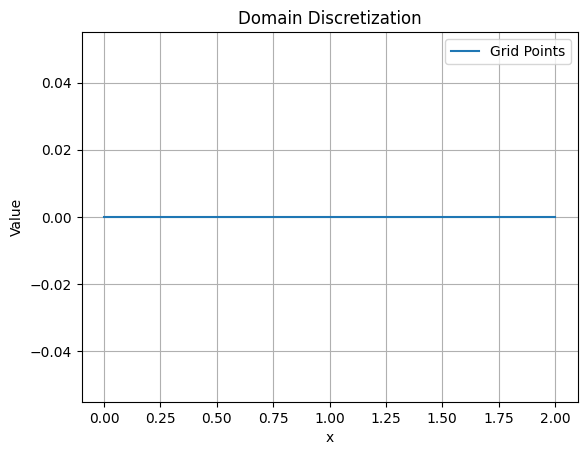

In [21]:
L = 2.0 # Length of the domain
N = 200 # Number of grid points

dx = L / N # Grid spacing

print("Grid spacing (dx):", dx)

x = np.linspace(0, L, N) # Grid points
print("Grid points (x):", x)

c = 1.0
cfl = 0.8

dt = cfl * dx / c # Time step size
print("Time step size (dt):", dt)

T = N * dt # Total simulation time
print("Total simulation time (T):", T)

plt.plot(x, np.zeros_like(x), label='Grid Points')
plt.title('Domain Discretization')
plt.xlabel('x')
plt.ylabel('Value')
plt.legend()
plt.grid()
plt.show()

### INITIAL CONDITION: A Gaussian pulse

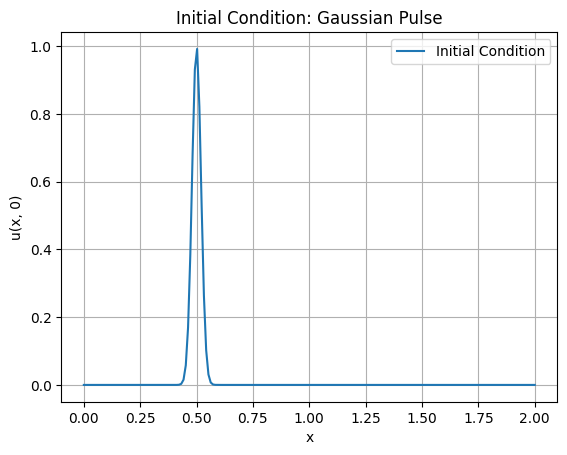

In [22]:
x0 = 0.5 # Initial position of the pulse
sigma = 0.02 # Width of the pulse

u0 = np.exp(-((x - x0) ** 2) / (2 * sigma ** 2)) # Initial condition
plt.plot(x, u0, label='Initial Condition')
plt.title('Initial Condition: Gaussian Pulse')
plt.xlabel('x')
plt.ylabel('u(x, 0)')
plt.legend()
plt.grid()
plt.show()

## Solver

In [ ]:
def advection_ftbs(u, c, dt, dx):
    u_new = np.copy(u)
    u_new[1:] = u[1:] - c * dt / dx * (u[1:] - u[:-1]) # FTBS scheme
    u_new[0] = u[0] - c * dt / dx * (u[0] - u[-1]) # Periodic boundary condition
    return u_new

